# A Simple Tutorial for TIC

## Installation

```bash
git clone https://github.com/cellethology/tic.git
cd tic
pip install -e .
```

## Load single cell data with anndata
To run tic pipeline, you have to make sure your anndata object has the following fields(minimum requirement):
- `X`: gene expression matrix
- `var`: gene names
- `obsm`: 'spatial' (x,y coordinates)

Optional:
- `obs`: cell type annotation
    please store cell type annotation in `adata.obs['cell_type']`, key = 'cell_type' (This will be used in feature extraction: select centre types)

Here is an example of how to load the CODEX UPMC data:
this will automatically download the data from the source and load it into anndata object.
The default data is stored in user's home directory(~). at .cache/tic/

If you want to remove the cache, you can run:
```bash
rm -rf ~/.cache/tic
```
or
```python
from tic.data import list_datasets, remove_cache, remove_dataset

list_datasets() # this will list all the datasets in the cache
remove_cache() # this will remove all the data in the cache
# if you want to remove a specific dataset, you can run:
remove_dataset("codex_upmc")
```







In [11]:
from tic.data import load_codex_upmc
example_data = load_codex_upmc()
print(example_data)
print(example_data.obs['cell_type'].unique())

AnnData object with n_obs × n_vars = 4360 × 22
    obs: 'cell_id', 'cell_type', 'size'
    uns: 'tissue_id', 'data_level'
    obsm: 'spatial'
['Naive immune cell' 'Macrophage' 'Stromal / Fibroblast' 'CD4 T cell'
 'Tumor (Ki67+)' 'Tumor (CD20+)' 'Tumor (CD21+)' 'Tumor (Podo+)' 'B cell'
 'Tumor' 'APC' 'Lymph vessel' 'CD8 T cell' 'Unassigned' 'Vessel'
 'Granulocyte' 'Tumor (CD15+)']


/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## Extract features from subgraph-based feature extractors
We have wrapped the subgraph-based feature extractors in the `tic.wrappers` module.
The following is an example of how to use the `FeatureWrapper` to extract features from the CODEX UPMC data.

Allowed subgraph strategies:
["knn", "radius", "k_hop_shortest", "k_hop_pyg", "bfs_python", "slice_adj"]

for 'k_hop_pyg' strategy, you need to install pytorch and torch-geometric(based on: torch_geometric.k_hop_subgraph)
```bash
pip install torch torch-geometric
```



In [2]:
from tic.wrappers import FeatureWrapper
print(FeatureWrapper.recipes())

['cell_basic', 'tme_default']


### if you want to use radius strategy, you need to specify the radius
Here we provide a function to estimate the radius based on the target microenv_size(default=30)
```python
from tic.graph.utils import estimate_radius
estimate_radius(example_data)
```



In [9]:
from tic.graph.utils import estimate_radius
estimate_radius(example_data)

101.41976385684654

In [10]:
from tic.wrappers import FeatureWrapper
feature_wrapper = FeatureWrapper(
    recipe="tme_default", 
    centre_types=["Tumor"], # This is compulsory, you must specify the centre type
    graph_params={'method':'voronoi'}, # You need to specify the way you want to build the image level graph
    subgraph_params={'strategy':'radius','radius':101}, # You need to specify the way you want to build the cell level subgraph
)
fea_adata = feature_wrapper.fit(example_data)
print(fea_adata)

AnnData object with n_obs × n_vars = 497 × 22
    obs: 'cell_id', 'cell_type', 'size'
    uns: 'feature_modes', 'graph_params', 'subgraph_params'
    obsm: 'centre_gene', 'composition', 'neighbor_gene_sum', 'same_type_gene_sum', 'same_type_gene_average', 'celltype_gene_count'


/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## Pseudotime Inference
In order to infer pseudotime, you need to specify:

2025-05-11 20:45:49,394 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isint(cluster_labels[0]):
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif isstr(cluster_labels[0]):
  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: in

,biomarker,mono_method,mono_correlation,mono_p_value,trend_method,trend_trend,trend_statistic,trend_p_value
0,CD11b,spearman,-0.255915,7.142665e-09,mann_kendall,no_trend,1.883834,0.059587
1,CD14,spearman,0.311617,1.183679e-12,mann_kendall,decreasing,-2.239351,0.025133
2,CD15,spearman,-0.101419,2.375183e-02,mann_kendall,decreasing,-3.003374,0.002670
3,CD163,spearman,-0.715263,4.685515e-79,mann_kendall,no_trend,1.450185,0.147007
4,CD20,spearman,-0.415912,3.282105e-22,mann_kendall,no_trend,1.147928,0.250998


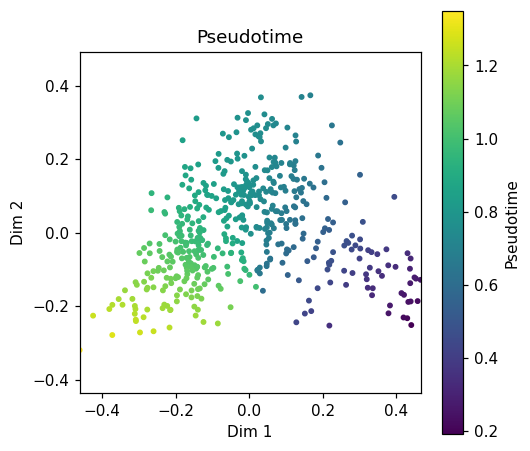

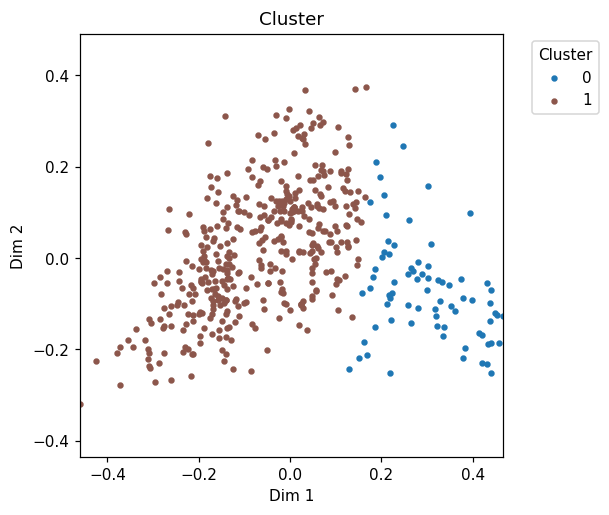

In [16]:
from tic.wrappers import PseudotimeWrapper
pseudotime_wrapper = PseudotimeWrapper(
    rep_key="composition", # This is the key you store representation vector(in .obsm)
    output_dir='../example', # This is the directory you want to save the pseudotime result.
)
pseudotime_adata = pseudotime_wrapper.fit(fea_adata)
pseudotime_wrapper.plot(kind="pseudotime")
pseudotime_wrapper.plot(kind="cluster")
pseudotime_wrapper.metrics.head()


### Visualization: Monotonicity Metrics Bar Chart


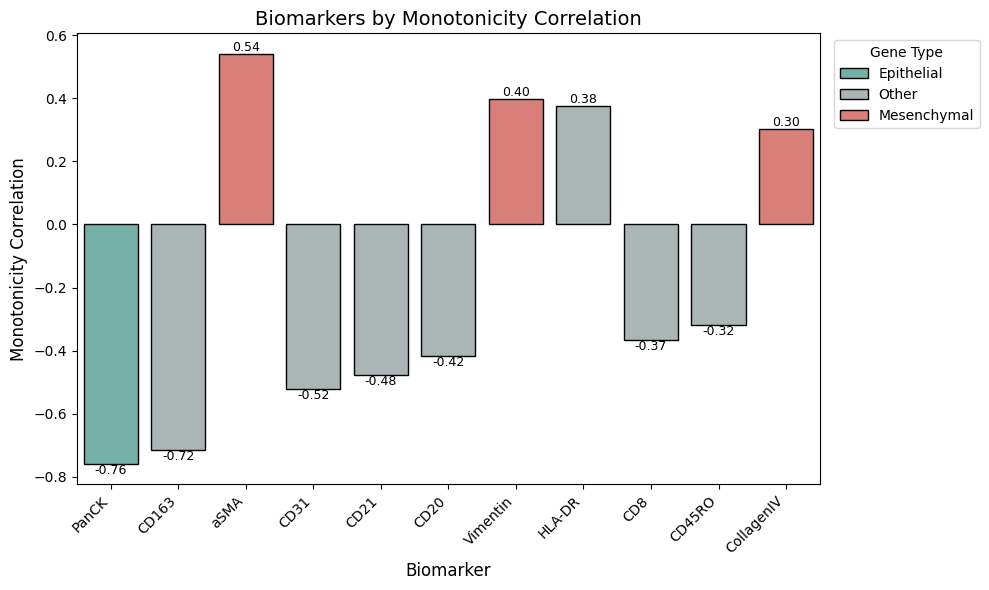

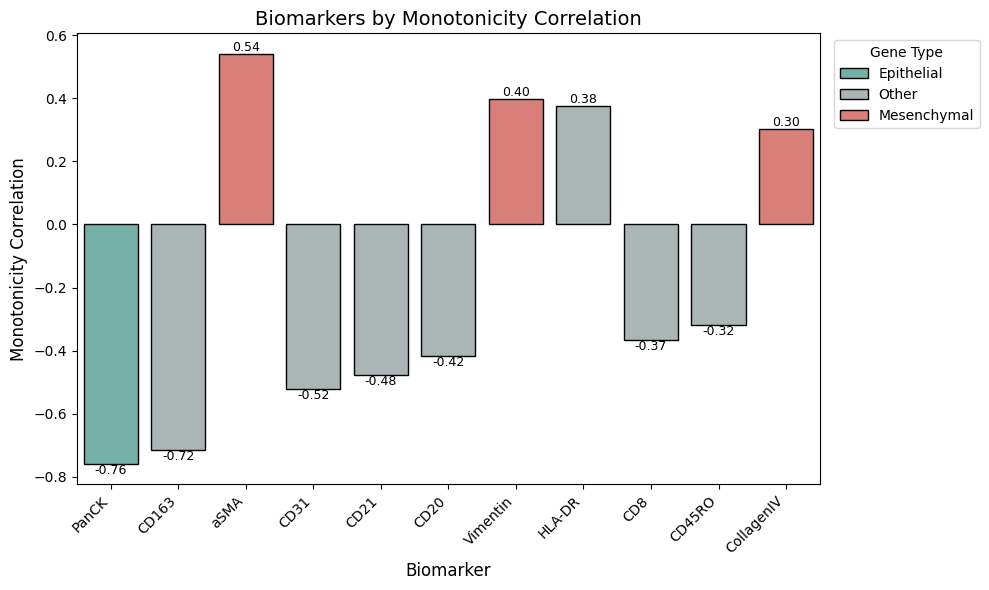

In [20]:
from tic.plotting import plot_monotonicity_metrics_bar
from utils.dataset.codex_upmc import UPMC_EPITHELIAL_GENES,UPMC_MESENCHYMAL_GENES
plot_monotonicity_metrics_bar(
    metrics=pseudotime_wrapper.metrics,
    show_top_n=10, # show the top n genes(include epithelial and mesenchymal genes)
    epithelial_genes = UPMC_EPITHELIAL_GENES, # will always show these genes
    mesenchymal_genes = UPMC_MESENCHYMAL_GENES, # will always show these genes
    save_path="../example/monotonicity_metrics_bar.png"
)

### Visualization: Biomarker vs Pseudotime
we provide a function to visualize the biomarker vs pseudotime



<Axes: title={'center': 'Biomarker Trends Along Pseudotime'}, xlabel='Pseudotime', ylabel='Expression normalize'>

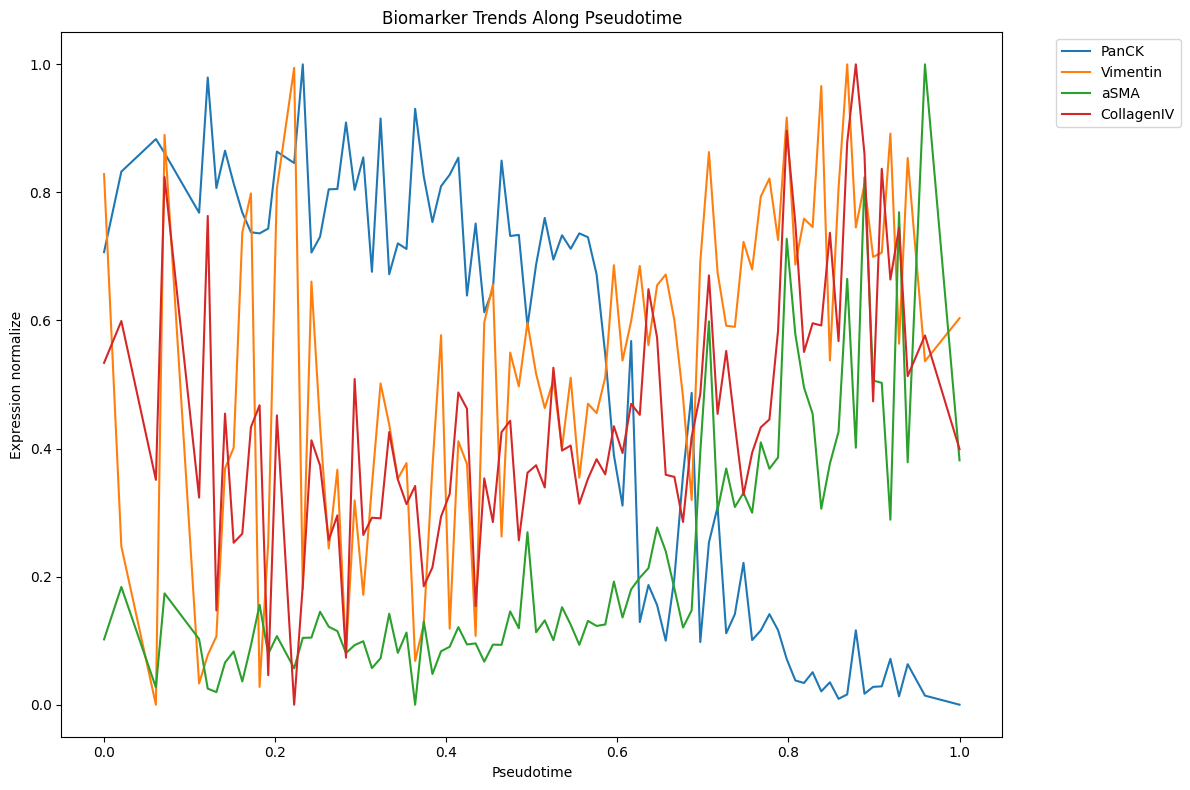

In [21]:
from tic.plotting import plot_biomarker_trends
plot_biomarker_trends(
    adata=pseudotime_adata,
    selected_biomarkers=UPMC_EPITHELIAL_GENES + UPMC_MESENCHYMAL_GENES, # specify the biomarkers you want to plot
    x_transform="bin+normalize",
    y_transform="normalize",
    bins=100,
    save_path="../example/biomarker_vs_pseudotime.png"
)
